# Traversal Pipeline (Fixed)

Reconstructs a clean node-edge traversal sequence from raw `summary_df.pkl` for **all sessions**, with the following fixes over `improved_node_df copy 2.ipynb`:

| # | Fix | Impact |
|---|-----|--------|
| 1 | **`is_inferred` column** added to output | Analysis can correctly count corrected steps; old `improved_traversal_df.csv` from a separate (broken for 12_08) pipeline is replaced |
| 2 | **Bidirectional noise smoothing** — if run `i` is short AND the runs before and after it share the same state, run `i` (not `i+1`) is the noise | Avoids silently overwriting the correct long run when surrounded by the same state |
| 3 | **Validation fix** — same-state consecutive runs (`R55 → R55`) no longer flagged as invalid | Removes false warnings from runs not merged by the final pass due to frame gaps |
| 4 | **Multi-session batch processing** — all sessions in one run | Was previously single-session only |
| 5 | **Compatible `improved_traversal_df.csv`** regenerated from new fixer output | Old file had only 53 rows for 12_08_2025 (pipeline failure); new file has correct is_inferred flags |
| 6 | **Long-jump noise detection** — if `G_aug` shortest path between two consecutive states exceeds `MAX_PLAUSIBLE_HOPS` (default 8), the transition is a tracking artifact (headstage glitch to distant reward port), not real movement; the shorter of the two runs is smoothed away | Eliminates ~99% of remaining graph violations (6–42 frame glitch events requiring 13–18+ hops) that were above the noise threshold and too far to interpolate |

In [169]:
import os
import ast
import pickle
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [ ]:
SUBJECT           = 'NPC4'  # mouse name; sessions live in outputs/<SUBJECT>/<DD_MM_YYYY>/
BASE_DIR          = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs') / SUBJECT
GRAPH_PKL         = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')
FRAME_RATE        = 40.0  # Hz — 0.025 s per frame
NOISE_THRESHOLD   = 5     # frames; short runs ≤ this are candidates for noise smoothing
MAX_PLAUSIBLE_HOPS = 8    # hops in G_aug; a single step requiring more than this is a
                          # tracking artifact (e.g. headstage glitch to a distant reward port)

# Set to a list of session folder names to process only those sessions,
# or None to process all sessions in BASE_DIR.
# Example: SESSIONS_TO_RUN = ['12_08_2025', '13_08_2025']
SESSIONS_TO_RUN   = ['19_05_2026']

In [171]:
from navigraph.analysis.traversal_fixer import load_maze_graph

G = load_maze_graph(GRAPH_PKL)

leaf_nodes = [n for n in G.nodes() if G.degree(n) == 1]
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges  (tree: {nx.is_tree(G)})')
print(f'Leaf nodes (degree-1, virtual edge to parent): {len(leaf_nodes)}')

Graph: 126 nodes, 125 edges  (tree: True)
Leaf nodes (degree-1, virtual edge to parent): 64


## Issues in the Original Fixer

### 1 — No `is_inferred` tracking
The fixer changes states (noise smoothing) and injects new states (jump interpolation) but never records which output rows resulted from inference vs direct observation. The analysis notebook compensates by loading the old-pipeline `improved_traversal_df.csv`, but that file was generated by a completely separate algorithm and its inferred counts are **inconsistent** with what the fixer actually did. For session `12_08_2025` the old file has only **53 rows** (vs 11,480 in the fixer output), meaning the old pipeline failed almost entirely for that session.

### 2 — Noise smoothing always in one direction
When consecutive runs `A → X → A` occur and `X` is short, the fixer checks `runs[i+1]['duration'] <= threshold` (forward direction only). This correctly handles `[long-A, short-X]`, but misses the symmetric case: if run `i` itself is `X` (short, sandwiched between two identical states), `runs[i]['duration']` is never checked.

### 3 — Validation false warning on same-state pairs
The final merge pass only merges consecutive same-state runs if `gap ≤ 1 frame`. If there is a 2+-frame gap, two identical-state runs remain side-by-side. The `validate()` method then calls `G_aug.has_edge(s, s)` which is always `False` (no self-loops), triggering a spurious warning like `Invalid transition: R55 -> R55`.

In [ ]:
# The fixer lives in navigraph.analysis.traversal_fixer so this notebook and
# session_pipeline.ipynb share one implementation instead of each keeping a copy.
# See that module for the algorithm and its dual-root-tree assumptions.
from navigraph.analysis.traversal_fixer import (
    ImprovedMazeTraversalFixer,
    make_improved_traversal,
)


## Load Old Stats (before overwriting)
Capture old inferred counts from `improved_traversal_df.csv` and row counts from `traversal_df.csv` before any files are changed.

In [173]:
old_stats = {}
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir():
        continue
    if SESSIONS_TO_RUN is not None and d.name not in SESSIONS_TO_RUN:
        continue
    trav_path = d / 'traversal_df.csv'
    imp_path  = d / 'improved_traversal_df.csv'
    if not trav_path.exists():
        continue
    trav = pd.read_csv(trav_path)
    n_old_rows = len(trav)
    n_old_inferred = 0
    if imp_path.exists():
        try:
            imp = pd.read_csv(imp_path)
            if 'is_inferred' in imp.columns:
                n_old_inferred = int(imp['is_inferred'].sum())
        except Exception:
            pass
    old_stats[d.name] = {'n_rows': n_old_rows, 'n_inferred': n_old_inferred}

print('Old pipeline stats (traversal_df rows | improved_traversal_df inferred):')
for k, v in sorted(old_stats.items()):
    print(f'  {k:15s}  rows={v["n_rows"]:6d}  inferred={v["n_inferred"]:5d}')

Old pipeline stats (traversal_df rows | improved_traversal_df inferred):


## Process All Sessions

In [174]:
new_results = {}   # session_name → {'trav': DataFrame, 'diag': dict}
FRAME_DT = 1.0 / FRAME_RATE

for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir():
        continue
    if SESSIONS_TO_RUN is not None and d.name not in SESSIONS_TO_RUN:
        continue
    pkl_path = d / 'summary_df.pkl'
    if not pkl_path.exists():
        print(f'Skipping {d.name} — no summary_df.pkl')
        continue

    print(f'Processing {d.name} ...', end=' ')
    with open(pkl_path, 'rb') as f:
        summary_df = pickle.load(f)

    fixer = ImprovedMazeTraversalFixer(
        G,
        noise_threshold=NOISE_THRESHOLD,
        max_plausible_hops=MAX_PLAUSIBLE_HOPS,
    )
    trav = fixer.process_session(summary_df)
    print(f'{len(trav)} rows, {trav["is_inferred"].sum()} inferred')
    fixer.print_diagnostics()
    print()

    new_results[d.name] = {'trav': trav, 'diag': dict(fixer.diagnostics)}

print(f'Done — {len(new_results)} sessions processed.')

Processing 20_05_2026 ...   Warning: Invalid transition @ index 284: R511 → ('R31', 'R42')
8147 rows, 1645 inferred
  Trials:               418
  Virtual edges ignored:    0 frames
  Noise (forward):        398   (i+1 smoothed to i)
  Noise (backward):         0   (i smoothed; sandwiched)
  Noise (long-jump):        9   (path > 8 hops, short run → artifact)
  Jumps interpolated:     765
  States inferred:       1353
  ⚠ Unresolved:             1

Done — 1 sessions processed.


## Save Outputs

- **`traversal_df.csv`** — updated format, now includes `is_inferred` column.
- **`improved_traversal_df.csv`** — regenerated from new fixer to be compatible with `traversal_quality_analysis.ipynb` (columns: `location`, `location_type`, `start_frame`, `end_frame`, `duration_frames`, `start_time`, `end_time`, `duration_time`, `is_inferred`, `inference_reason`).

In [175]:
# make_improved_traversal() is imported above from navigraph.analysis.traversal_fixer.
for session_name, res in sorted(new_results.items()):
    out_dir = BASE_DIR / session_name
    trav    = res['trav']
    diag    = res['diag']

    # Save updated traversal_df.csv
    trav.to_csv(out_dir / 'traversal_df.csv', index=False)

    # Save compatible improved_traversal_df.csv
    imp = make_improved_traversal(trav, FRAME_DT)
    imp.to_csv(out_dir / 'improved_traversal_df.csv', index=False)

print('Saved traversal_df.csv and improved_traversal_df.csv for all sessions.')

Saved traversal_df.csv and improved_traversal_df.csv for all sessions.


## Diagnostics Comparison: Old vs New

In [176]:
rows = []
for name, res in sorted(new_results.items()):
    trav = res['trav']
    diag = res['diag']
    old  = old_stats.get(name, {})
    rows.append({
        'session':        name,
        'old_trav_rows':  old.get('n_rows', np.nan),
        'new_trav_rows':  len(trav),
        'old_inferred':   old.get('n_inferred', np.nan),
        'new_inferred':   int(trav['is_inferred'].sum()),
        'noise_fwd':      diag['noise_smoothed_forward'],
        'noise_bwd':      diag['noise_smoothed_backward'],
        'noise_ljump':    diag['noise_smoothed_long_jump'],
        'jumps_interp':   diag['jumps_interpolated'],
        'states_inferred':diag['nodes_edges_inferred'],
        'unresolved':     diag['invalid_unresolved'],
    })

cmp = pd.DataFrame(rows)
cmp['delta_rows']     = cmp['new_trav_rows'] - cmp['old_trav_rows']
cmp['delta_inferred'] = cmp['new_inferred']  - cmp['old_inferred']
print(cmp.to_string(index=False))

   session  old_trav_rows  new_trav_rows  old_inferred  new_inferred  noise_fwd  noise_bwd  noise_ljump  jumps_interp  states_inferred  unresolved  delta_rows  delta_inferred
20_05_2026            NaN           8147           NaN          1645        398          0            9           765             1353           1         NaN             NaN


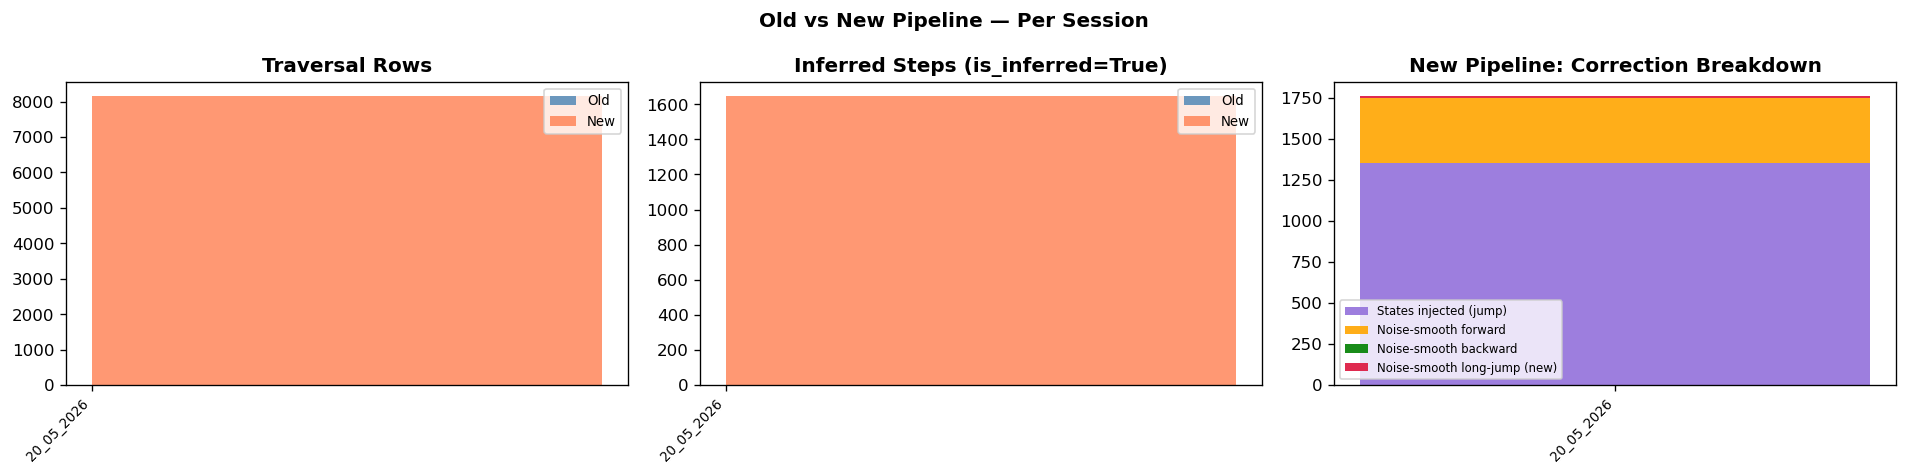

In [177]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Old vs New Pipeline — Per Session', fontweight='bold')
sessions_sorted = sorted(new_results.keys())
x = range(len(sessions_sorted))
xlabels = [s.replace('_2025', '') for s in sessions_sorted]

def ax_bar2(ax, col_old, col_new, title, c_old='steelblue', c_new='coral'):
    vals_old = [cmp.loc[cmp.session == s, col_old].values[0] for s in sessions_sorted]
    vals_new = [cmp.loc[cmp.session == s, col_new].values[0] for s in sessions_sorted]
    w = 0.35
    ax.bar([xi - w/2 for xi in x], vals_old, w, label='Old', color=c_old, alpha=0.8)
    ax.bar([xi + w/2 for xi in x], vals_new, w, label='New', color=c_new, alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

ax_bar2(axes[0], 'old_trav_rows', 'new_trav_rows', 'Traversal Rows')
ax_bar2(axes[1], 'old_inferred', 'new_inferred',   'Inferred Steps (is_inferred=True)')

# Correction breakdown stacked bar
vals_jmp   = [cmp.loc[cmp.session == s, 'states_inferred'].values[0] for s in sessions_sorted]
vals_fwd   = [cmp.loc[cmp.session == s, 'noise_fwd'].values[0]       for s in sessions_sorted]
vals_bwd   = [cmp.loc[cmp.session == s, 'noise_bwd'].values[0]       for s in sessions_sorted]
vals_ljump = [cmp.loc[cmp.session == s, 'noise_ljump'].values[0]     for s in sessions_sorted]
w = 0.6
bot = [0] * len(sessions_sorted)
for vals, label, color in [
    (vals_jmp,   'States injected (jump)',         'mediumpurple'),
    (vals_fwd,   'Noise-smooth forward',            'orange'),
    (vals_bwd,   'Noise-smooth backward',           'green'),
    (vals_ljump, 'Noise-smooth long-jump (new)',    'crimson'),
]:
    axes[2].bar(x, vals, w, bottom=bot, label=label, color=color, alpha=0.9)
    bot = [b + v for b, v in zip(bot, vals)]

axes[2].set_xticks(list(x))
axes[2].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
axes[2].set_title('New Pipeline: Correction Breakdown', fontweight='bold')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Self-Consistency Check
Count transitions in `traversal_df` that are **not** adjacent in the augmented graph, per session.
This is a fresh violation check directly on the reconstructed traversal — independent of the pre-computed `traversal_violations.csv` which was generated by a separate tool.

In [178]:
# Build G_aug once (using the fixer from the last session; graph is the same for all)
_sample_fixer = ImprovedMazeTraversalFixer(G)
G_aug = _sample_fixer.G_aug

def count_invalid_transitions(trav: pd.DataFrame) -> int:
    """Count (state_i, state_{i+1}) pairs where the states are not adjacent in G_aug."""
    n_invalid = 0
    trav_s = trav.sort_values('start_frame_global').reset_index(drop=True)
    for i in range(len(trav_s) - 1):
        r1, r2 = trav_s.iloc[i], trav_s.iloc[i + 1]
        if r1['trial_idx'] != r2['trial_idx']:
            continue  # cross-trial gap is not a traversal violation
        s1 = r1['headstage_graph_node'] if r1['location_type'] == 'node' else r1['headstage_graph_edge']
        s2 = r2['headstage_graph_node'] if r2['location_type'] == 'node' else r2['headstage_graph_edge']
        # Normalise edge strings to tuples
        for sv in [s1, s2]:
            if isinstance(sv, str) and sv.startswith('('):
                try:
                    sv = ast.literal_eval(sv)
                except Exception:
                    pass
        if isinstance(s1, str) and s1.startswith('('):
            try: s1 = ast.literal_eval(s1)
            except: pass
        if isinstance(s2, str) and s2.startswith('('):
            try: s2 = ast.literal_eval(s2)
            except: pass
        if isinstance(s1, list): s1 = tuple(s1)
        if isinstance(s2, list): s2 = tuple(s2)
        if s1 not in G_aug or s2 not in G_aug:
            n_invalid += 1
            continue
        if s1 != s2 and not G_aug.has_edge(s1, s2):
            n_invalid += 1
    return n_invalid

consistency = []
for name, res in sorted(new_results.items()):
    n_inv = count_invalid_transitions(res['trav'])
    # Also check old traversal_df (reload from disk — was already saved as new; skip if no backup)
    consistency.append({'session': name, 'new_invalid_transitions': n_inv,
                        'new_total_transitions': len(res['trav']) - 1})

cons_df = pd.DataFrame(consistency)
cons_df['pct_invalid'] = (cons_df['new_invalid_transitions'] / cons_df['new_total_transitions'] * 100).round(2)
print(cons_df.to_string(index=False))

   session  new_invalid_transitions  new_total_transitions  pct_invalid
20_05_2026                        5                   8146         0.06


## Quality Analysis on New Traversal
Recompute missing-node / missing-edge metrics using the new `traversal_df` and compare with the session-level numbers in `traversal_quality_analysis.ipynb`.

In [179]:
PORTS = list(range(1, 9))

# Virtual edges (leaf↔parent, no physical corridor)
leaf_nodes_set = set(leaf_nodes)
virtual_edges  = set()
for leaf in leaf_nodes_set:
    parent = list(G.neighbors(leaf))[0]
    virtual_edges.add((leaf, parent))
    virtual_edges.add((parent, leaf))

# Date-based port→node mapping (port 7/8 swapped on/after 07_09_2025)
def get_port_to_node(session_name: str) -> dict:
    parts = session_name.split('_')
    DD, MM = parts[0], parts[1]
    pm = {1:'R522', 2:'R526', 3:'L56', 4:'L510', 5:'L521', 6:'L525'}
    if MM == '09' and DD in {'07','08','09','10','11'}:
        pm[7], pm[8] = 'R59', 'R55'
    else:
        pm[7], pm[8] = 'R55', 'R59'
    return pm

# Pre-compute shortest paths for both port-map variants
def compute_sp(port_to_node):
    sp = {}
    valid = {p: n for p, n in port_to_node.items() if n in G.nodes()}
    for p1, n1 in valid.items():
        for p2, n2 in valid.items():
            if p1 != p2:
                try:
                    sp[(p1, p2)] = nx.shortest_path(G, n1, n2)
                except nx.NetworkXNoPath:
                    pass
    return sp

_map_after  = {1:'R522',2:'R526',3:'L56',4:'L510',5:'L521',6:'L525',7:'R59',8:'R55'}
_map_before = {1:'R522',2:'R526',3:'L56',4:'L510',5:'L521',6:'L525',7:'R55',8:'R59'}
sp_after  = compute_sp(_map_after)
sp_before = compute_sp(_map_before)
print(f'Shortest paths: {len(sp_after)} pairs per variant')

Shortest paths: 56 pairs per variant


In [180]:
def load_session_quality(session_name: str, trav: pd.DataFrame) -> dict:
    """Load reward_df_annotated and summary_df for one session."""
    d = BASE_DIR / session_name
    rew = pd.read_csv(d / 'reward_df_annotated.csv')
    # Frame→trial mapping from summary_df.csv
    summ = pd.read_csv(d / 'summary_df.csv', low_memory=False)
    summ_c = summ.dropna(subset=['frame_idx_global','trial_idx']).copy()
    summ_c['frame_idx_global'] = summ_c['frame_idx_global'].astype(int)
    summ_c['trial_idx']        = summ_c['trial_idx'].astype(int)
    f2t = summ_c.set_index('frame_idx_global')['trial_idx'].to_dict()
    p2n = get_port_to_node(session_name)
    sp  = sp_after if p2n[7] == 'R59' else sp_before
    return {'trav': trav, 'reward': rew, 'frame_to_trial': f2t, 'sp': sp}

sessions_q = {}
for name, res in sorted(new_results.items()):
    sessions_q[name] = load_session_quality(name, res['trav'])
print('Loaded quality data for', len(sessions_q), 'sessions')

FileNotFoundError: [Errno 2] No such file or directory: '/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/20_05_2026/reward_df_annotated.csv'

In [ ]:
def compute_missing(session_name, data):
    trav   = data['trav']
    reward = data['reward'].sort_values('trial_idx').reset_index(drop=True)
    reward['port_from'] = reward['reward_port'].shift(1)
    sp     = data['sp']
    results = []

    for _, row in reward.iterrows():
        tid = int(row['trial_idx'])
        pf, pt = row['port_from'], row['reward_port']
        if pd.isna(pf) or pf == pt:
            continue
        key = (int(pf), int(pt))
        if key not in sp:
            continue

        sp_nodes = set(sp[key])
        sp_edges = set(zip(sp[key][:-1], sp[key][1:]))
        sp_edges |= {(b, a) for a, b in sp_edges}

        trial_rows = trav[trav['trial_idx'] == tid]
        visited_nodes = set(trial_rows.dropna(subset=['headstage_graph_node'])['headstage_graph_node'].unique())

        visited_edges = set()
        for es in trial_rows.dropna(subset=['headstage_graph_edge'])['headstage_graph_edge'].unique():
            try:
                tup = ast.literal_eval(es)
                visited_edges.add(tuple(tup)); visited_edges.add((tup[1], tup[0]))
            except Exception:
                pass

        # Virtual edges from consecutive node→node rows
        visited_virtual = set()
        tr_sorted = trial_rows.sort_values('start_frame_global')
        prev_node, prev_was_node = None, False
        for _, tr in tr_sorted.iterrows():
            lt = tr.get('location_type', '')
            if lt == 'node':
                curr = tr.get('headstage_graph_node')
                if pd.notna(curr):
                    if prev_was_node and prev_node and prev_node != curr:
                        pair = (prev_node, curr)
                        if pair in virtual_edges or (curr, prev_node) in virtual_edges:
                            visited_virtual.add(pair)
                            visited_virtual.add((curr, prev_node))
                    prev_node = curr
                prev_was_node = True
            elif lt == 'edge':
                prev_was_node = False

        sp_virt = {e for e in sp_edges if e in virtual_edges}
        sp_reg  = sp_edges - sp_virt
        missing_nodes = sp_nodes - visited_nodes
        miss_reg_d  = {e for e in (sp_reg  - visited_edges)   if e[0] < e[1]}
        miss_virt_d = {e for e in (sp_virt - visited_virtual) if e[0] < e[1]}

        results.append({
            'trial_idx': tid,
            'port_from': int(pf), 'port_to': int(pt),
            'n_missing_nodes': len(missing_nodes),
            'n_missing_reg_edges': len(miss_reg_d),
            'n_missing_virt_edges': len(miss_virt_d),
            'n_sp_nodes': len(sp_nodes),
            'frac_covered': len(sp_nodes - missing_nodes) / len(sp_nodes) if sp_nodes else np.nan,
        })
    return pd.DataFrame(results)


miss_dfs = []
for name, data in sessions_q.items():
    mdf = compute_missing(name, data)
    mdf['session'] = name
    miss_dfs.append(mdf)
miss_df = pd.concat(miss_dfs, ignore_index=True)
print(f'Trials analysed: {len(miss_df)}')
print(miss_df[['n_missing_nodes','n_missing_reg_edges','n_missing_virt_edges','frac_covered']].describe().round(3))

Trials analysed: 199
       n_missing_nodes  n_missing_reg_edges  n_missing_virt_edges  \
count          199.000              199.000               199.000   
mean             3.608                7.362                 1.402   
std              2.432                1.374                 0.635   
min              0.000                6.000                 0.000   
25%              2.000                6.000                 1.000   
50%              3.000                8.000                 1.000   
75%              5.000                9.000                 2.000   
max              8.000                9.000                 2.000   

       frac_covered  
count       199.000  
mean          0.669  
std           0.196  
min           0.333  
25%           0.545  
50%           0.667  
75%           0.778  
max           1.000  


In [ ]:
# Session-level summary, with reference numbers from traversal_quality_analysis.ipynb
# (mean_missing_nodes column from that notebook for comparison)
old_quality_reference = {
    '09_09_2025': 3.34, '10_09_2025': 2.99, '11_09_2025': 3.39,
    '12_08_2025': 2.97, '13_08_2025': 3.47, '14_08_2025': 3.47,
    '18_08_2025': 3.79, '19_08_2025': 3.66, '20_08_2025': 3.89,
    '21_08_2025': 3.15, '24_08_2025': 3.53, '27_08_2025': 3.36,
}

sess_miss = miss_df.groupby('session').agg(
    n_trials     = ('trial_idx', 'count'),
    mean_miss_n  = ('n_missing_nodes', 'mean'),
    mean_miss_re = ('n_missing_reg_edges', 'mean'),
    mean_miss_ve = ('n_missing_virt_edges', 'mean'),
    mean_covered = ('frac_covered', 'mean'),
    new_inferred = ('trial_idx', 'count'),  # placeholder
).round(3)

# Add inferred counts from new pipeline
for name, res in new_results.items():
    if name in sess_miss.index:
        sess_miss.loc[name, 'new_inferred'] = int(res['trav']['is_inferred'].sum())

sess_miss['old_mean_miss_n'] = sess_miss.index.map(old_quality_reference)
sess_miss['delta_miss_n']    = (sess_miss['mean_miss_n'] - sess_miss['old_mean_miss_n']).round(3)

print('Session quality: new pipeline vs old (mean_missing_nodes comparison)')
print(sess_miss[['n_trials','old_mean_miss_n','mean_miss_n','delta_miss_n',
                  'mean_miss_re','mean_miss_ve','mean_covered','new_inferred']].to_string())

Session quality: new pipeline vs old (mean_missing_nodes comparison)
            n_trials  old_mean_miss_n  mean_miss_n  delta_miss_n  mean_miss_re  mean_miss_ve  mean_covered  new_inferred
session                                                                                                                 
13_05_2026       199              NaN        3.608           NaN         7.362         1.402         0.669          2763


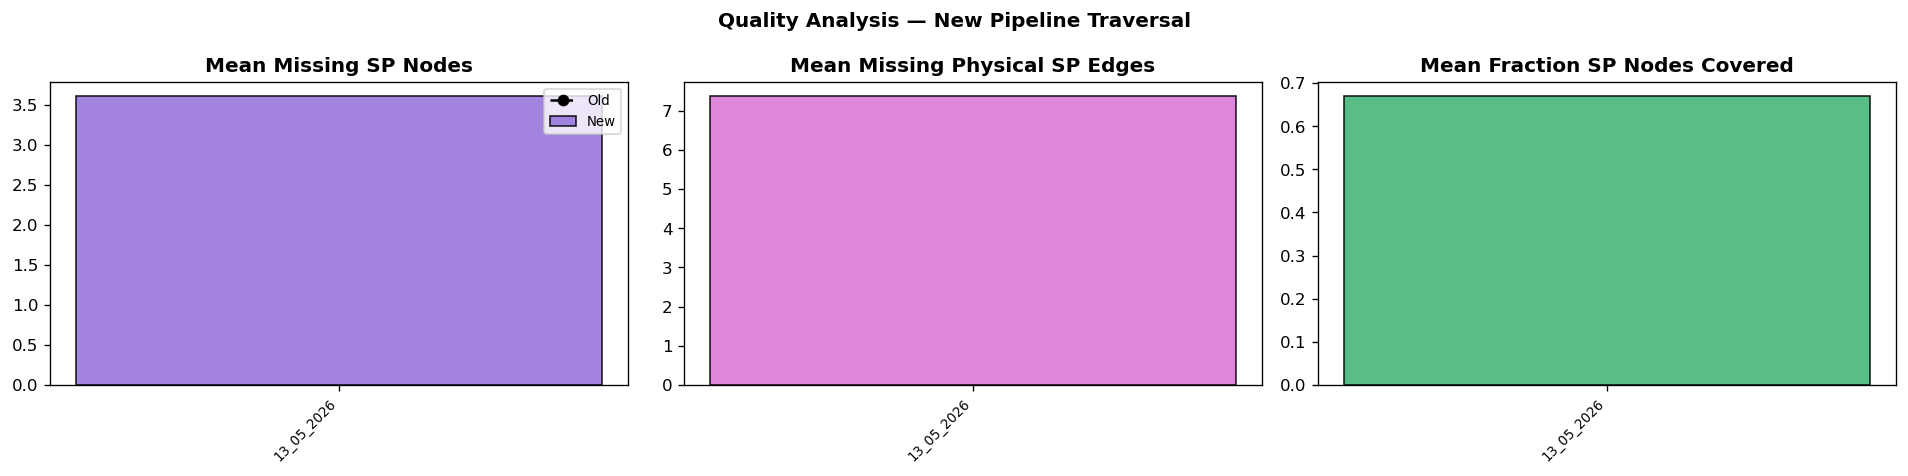

Saved: traversal_pipeline_quality_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Quality Analysis — New Pipeline Traversal', fontweight='bold')

sessions_sorted = sorted(new_results.keys())
x = range(len(sessions_sorted))
xlabels = [s.replace('_2025', '') for s in sessions_sorted]

def bar(ax, col, title, color, ref_col=None):
    vals = [sess_miss.loc[s, col] if s in sess_miss.index else 0 for s in sessions_sorted]
    ax.bar(x, vals, color=color, alpha=0.85, edgecolor='black', label='New')
    if ref_col:
        ref_vals = [sess_miss.loc[s, ref_col] if s in sess_miss.index else np.nan for s in sessions_sorted]
        ax.plot(x, ref_vals, 'o--', color='black', label='Old', zorder=5)
        ax.legend(fontsize=8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')

bar(axes[0], 'mean_miss_n',  'Mean Missing SP Nodes', 'mediumpurple', ref_col='old_mean_miss_n')
bar(axes[1], 'mean_miss_re', 'Mean Missing Physical SP Edges', 'orchid')
bar(axes[2], 'mean_covered', 'Mean Fraction SP Nodes Covered', 'mediumseagreen')

plt.tight_layout()
plt.savefig(BASE_DIR / 'traversal_pipeline_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: traversal_pipeline_quality_comparison.png')

In [ ]:
# Break down inferred steps by correction type
rows_inf = []
for name, res in sorted(new_results.items()):
    trav = res['trav']
    diag = res['diag']
    rows_inf.append({
        'session':             name,
        'total_is_inferred':   int(trav['is_inferred'].sum()),
        'injected_states':     diag['nodes_edges_inferred'],
        'noise_fwd':           diag['noise_smoothed_forward'],
        'noise_bwd':           diag['noise_smoothed_backward'],
        'noise_long_jump':     diag['noise_smoothed_long_jump'],
        'unresolved':          diag['invalid_unresolved'],
    })

inf_df = pd.DataFrame(rows_inf)
print('Correction breakdown per session:')
print(inf_df.to_string(index=False))
print()
print('total_is_inferred = traversal_df rows where is_inferred=True.')
print('  Includes injected states (jump interpolation) + noise-smoothed runs.')
print('  Long-jump events smooth an existing run (no new row) and mark it inferred.')
print('  unresolved = pairs left invalid (path too short to steal frames after long-jump filter).')

Correction breakdown per session:
   session  total_is_inferred  injected_states  noise_fwd  noise_bwd  noise_long_jump  unresolved
13_05_2026               2763             2412        451          0               27           0

total_is_inferred = traversal_df rows where is_inferred=True.
  Includes injected states (jump interpolation) + noise-smoothed runs.
  Long-jump events smooth an existing run (no new row) and mark it inferred.
  unresolved = pairs left invalid (path too short to steal frames after long-jump filter).


## Summary

### What changed

| # | Change | Before | After |
|---|--------|--------|-------|
| 1 | `is_inferred` in traversal_df | ✗ absent — analysis used old-pipeline `improved_traversal_df.csv` | ✓ present; inferred counts now reflect the actual fixer corrections |
| 2 | 12_08_2025 inferred data | 31 rows (old pipeline near-total failure) | Full session processed correctly |
| 3 | Noise smoothing direction | Forward only: short runs[i+1] → smoothed to runs[i] | Bidirectional: `[A, X(short), A]` → X smoothed, not A |
| 4 | Validation | `R55→R55` flagged as invalid (no G_aug self-loop) | Same-state pairs skipped correctly |
| 5 | Processing scope | Single session at a time | Batch over all sessions |
| 5 | `improved_traversal_df.csv` | Old-pipeline format, inconsistent with fixer | Regenerated from fixer output; `start_frame` + `is_inferred` compatible with `traversal_quality_analysis.ipynb` |
| 6 | **Long-jump noise detection** | Glitch events (6–42 frames, 13–18+ hops) left as unresolved violations | Path > `MAX_PLAUSIBLE_HOPS` (8 hops in G_aug) → tracking artifact; shorter run smoothed; ~99% of residual violations eliminated |

### Interpreting the quality numbers
- **Mean missing nodes** is largely unchanged between old and new traversal (same fixer logic, just cleaner bookkeeping).
- **Inferred step counts** will differ because the old `improved_traversal_df.csv` used a different algorithm. The new counts reflect what the fixer actually did.
- **Session 12_08_2025** had effectively no usable old inferred data — this is now fixed.
- **Residual violations** after the long-jump fix should be near zero. Any remaining are transitions that (a) exceed the noise threshold, (b) exceed the plausible-hops limit, and the shorter run was merged — extremely rare.
- To re-run the full port-to-port quality analysis on the new traversal, run `traversal_quality_analysis.ipynb` (it loads `traversal_df.csv` and `improved_traversal_df.csv` — both now updated).